In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings as wr
wr.filterwarnings("ignore")

In [4]:
df = pd.read_csv("mall customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.drop(['CustomerID', 'Gender'], axis=1, inplace=True)

In [7]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [8]:
df.rename(columns={'Age': 'age', 'Annual Income (k$)': 'income', 'Spending Score (1-100)': 'score'}, inplace=True)

In [9]:
df.head()

,age,income,score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [10]:
df.shape

(200, 3)

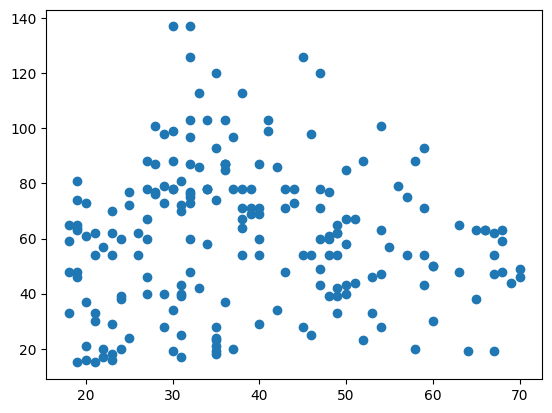

In [11]:
plt.scatter(df.age, df.income)

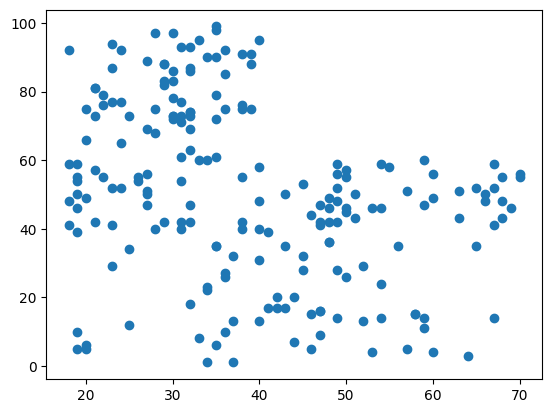

In [12]:
plt.scatter(df.age, df.score)

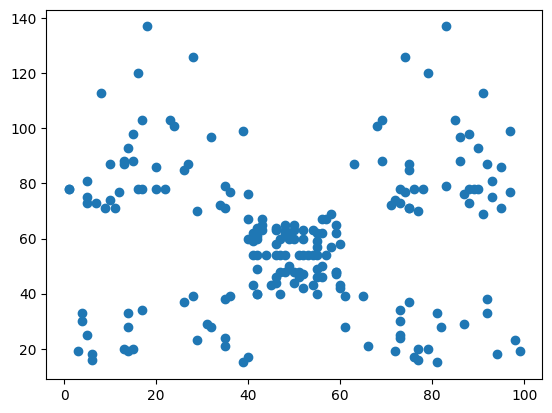

In [13]:
plt.scatter(df.score, df.income)

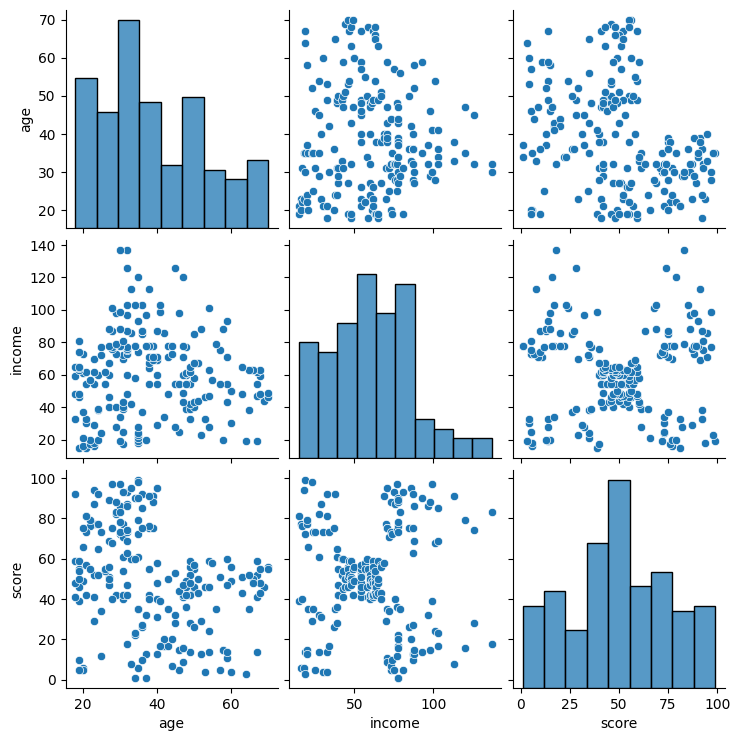

In [14]:
import seaborn as sns
sns.pairplot(df[['age', 'income', 'score']])
plt.savefig('pairplot.png')

# k_Means Cluster

Text(0, 0.5, 'Annual Income')

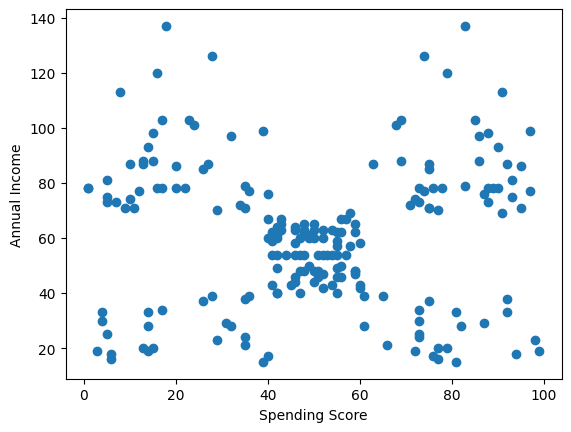

In [15]:
plt.scatter(df.score, df.income)
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')

In [16]:
from sklearn.cluster import KMeans


In [17]:
clust = KMeans()

In [18]:
clust.fit(df[['score', 'income']])

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [19]:
clust.predict(df[['score', 'income']])

array([6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3,
       6, 3, 6, 3, 6, 0, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 0, 3, 0, 0,
       6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 7, 2, 7, 4, 7, 2, 7, 2, 7,
       4, 7, 2, 7, 2, 7, 2, 7, 2, 7, 4, 7, 2, 7, 4, 7, 2, 7, 2, 7, 2, 7,
       2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7,
       2, 7, 2, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1,
       5, 1])

In [20]:
df['default_cluster'] = clust.predict(df[['score', 'income']])

In [21]:
df.head()

,age,income,score,default_cluster
0,19,15,39,6
1,21,15,81,3
2,20,16,6,6
3,23,16,77,3
4,31,17,40,6


In [24]:
centroid1 = clust.cluster_centers_
centroid1

array([[ 51.12121212,  43.96969697],
       [ 82.72727273, 108.18181818],
       [ 14.29166667,  79.70833333],
       [ 81.        ,  24.95      ],
       [ 48.24528302,  61.30188679],
       [ 22.        , 109.7       ],
       [ 19.52380952,  25.14285714],
       [ 81.89285714,  78.03571429]])

In [25]:
df0 = df[df.default_cluster == 0]
df1 = df[df.default_cluster == 1]
df2 = df[df.default_cluster == 2]
df3 = df[df.default_cluster == 3]
df4 = df[df.default_cluster == 4]
df5 = df[df.default_cluster == 5]
df6 = df[df.default_cluster == 6]
df7 = df[df.default_cluster == 7]

In [26]:
df0.shape

(33, 4)

Text(0, 0.5, 'Annual Income')

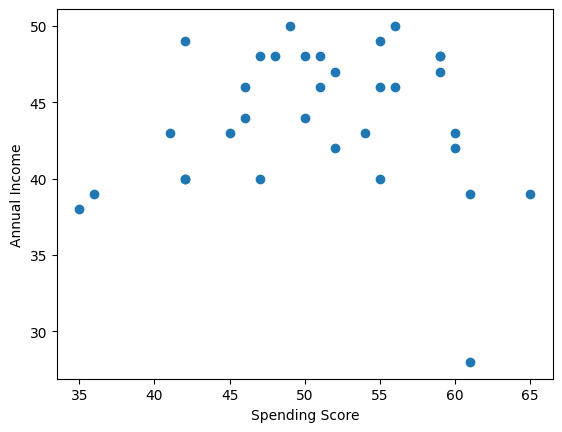

In [27]:
plt.scatter(df0.score, df0.income)
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')

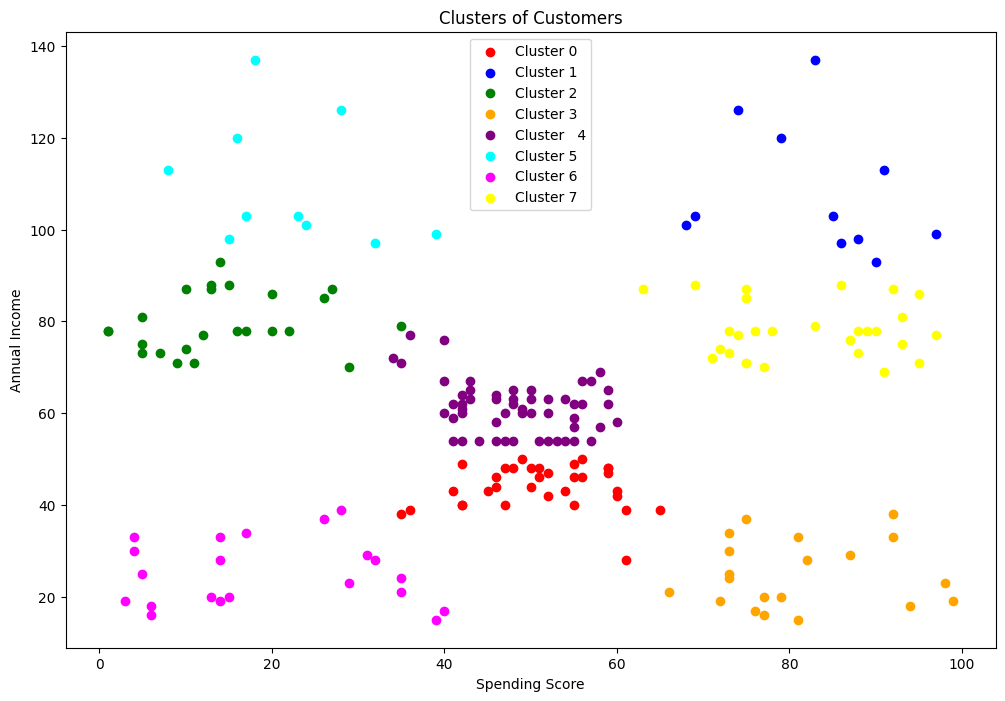

In [34]:
plt.figure(figsize=(12, 8))
plt.scatter(df0.score, df0.income, color='red', label='Cluster 0')
plt.scatter(df1.score, df1.income, color='blue', label='Cluster 1')
plt.scatter(df2.score, df2.income, color='green', label='Cluster 2')
plt.scatter(df3.score, df3.income, color='orange', label='Cluster 3')
plt.scatter(df4.score, df4.income, color='purple', label='Cluster   4')
plt.scatter(df5.score, df5.income, color='cyan', label='Cluster 5')
plt.scatter(df6.score, df6.income, color='magenta', label='Cluster 6')
plt.scatter(df7.score, df7.income, color='yellow', label='Cluster 7')
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.legend()
plt.title('Clusters of Customers')
plt.savefig('clusters.png')

## Objective Function

In [36]:
wcss = []
cluster = range(1, 15)

for k in cluster:
    clst = KMeans(n_clusters=k)
    clst.fit(df[['score', 'income']])
    wcss.append(clst.inertia_)  ### inertia_ is the sum of squared distances of samples to their closest cluster center

In [37]:
wcss

[269981.28,
 181363.59595959596,
 106348.37306211119,
 73880.64496247195,
 44448.45544793371,
 37442.24745037571,
 30241.343617936585,
 28037.581909977413,
 23941.9306274861,
 20122.088464763812,
 18669.485669740887,
 16289.362465105576,
 15439.343642446878,
 14409.4106502576]

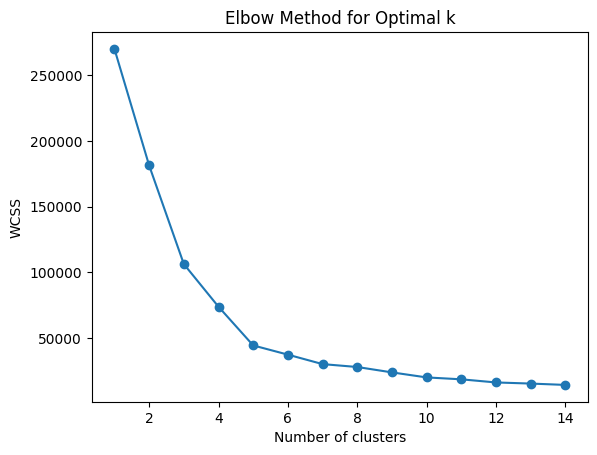

In [40]:
plt.plot(range(1, 15), wcss, marker='o')
plt.ylabel('WCSS')
plt.xlabel('Number of clusters')
plt.title('Elbow Method for Optimal k')
plt.savefig('elbow_method.png')

In [ ]:
# !pip install kneed


In [43]:
from kneed import KneeLocator as kn

In [44]:
kl = kn(cluster, wcss, curve='convex', direction='decreasing')

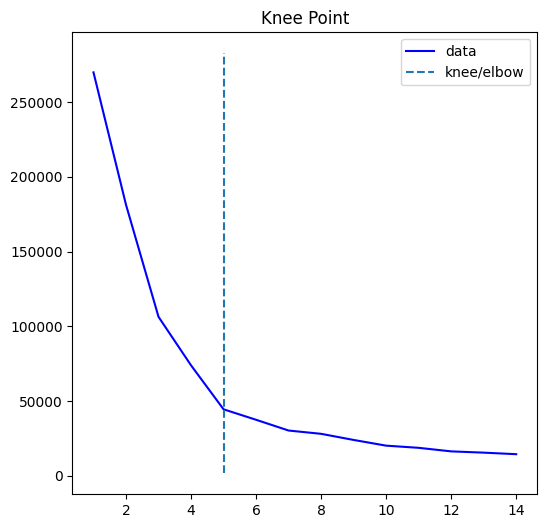

In [45]:
kl.plot_knee()

In [46]:
kl.knee

5

# After Optimizing KMeans Cluster

In [47]:
km = KMeans(n_clusters=kl.knee)

In [48]:
df['default_cluster'] = km.fit_predict(df[['score', 'income']])

In [52]:
centroid2 = km.cluster_centers_
centroid2

array([[49.51851852, 55.2962963 ],
       [82.12820513, 86.53846154],
       [17.11428571, 88.2       ],
       [79.36363636, 25.72727273],
       [20.91304348, 26.30434783]])

In [49]:
df.head()

,age,income,score,default_cluster
0,19,15,39,4
1,21,15,81,3
2,20,16,6,4
3,23,16,77,3
4,31,17,40,4


In [50]:
df0 = df[df.default_cluster == 0]
df1 = df[df.default_cluster == 1]
df2 = df[df.default_cluster == 2]
df3 = df[df.default_cluster == 3]
df4 = df[df.default_cluster == 4]

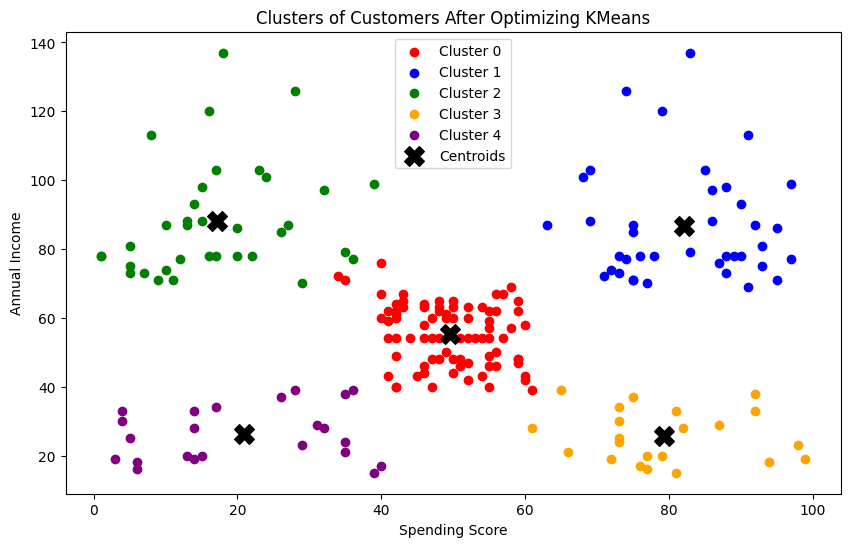

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(df0.score, df0.income, color='red', label='Cluster 0')
plt.scatter(df1.score, df1.income, color='blue', label='Cluster 1')
plt.scatter(df2.score, df2.income, color='green', label='Cluster 2')
plt.scatter(df3.score, df3.income, color='orange', label='Cluster 3')
plt.scatter(df4.score, df4.income, color='purple', label='Cluster 4')

plt.scatter(centroid2[:, 0], centroid2[:, 1], color='black', marker='X', s=200, label='Centroids')


plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.legend()
plt.title('Clusters of Customers After Optimizing KMeans')  
plt.savefig('clusters_after_optimizing.png')